In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/patelris/crop-yield-prediction-dataset/yield.csv
/kaggle/input/datasets/patelris/crop-yield-prediction-dataset/temp.csv
/kaggle/input/datasets/patelris/crop-yield-prediction-dataset/rainfall.csv
/kaggle/input/datasets/patelris/crop-yield-prediction-dataset/pesticides.csv
/kaggle/input/datasets/patelris/crop-yield-prediction-dataset/yield_df.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("/kaggle/input/datasets/patelris/crop-yield-prediction-dataset/yield_df.csv")

In [4]:
df.shape

(28242, 8)

In [5]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [7]:
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [8]:
df.isna().sum()

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

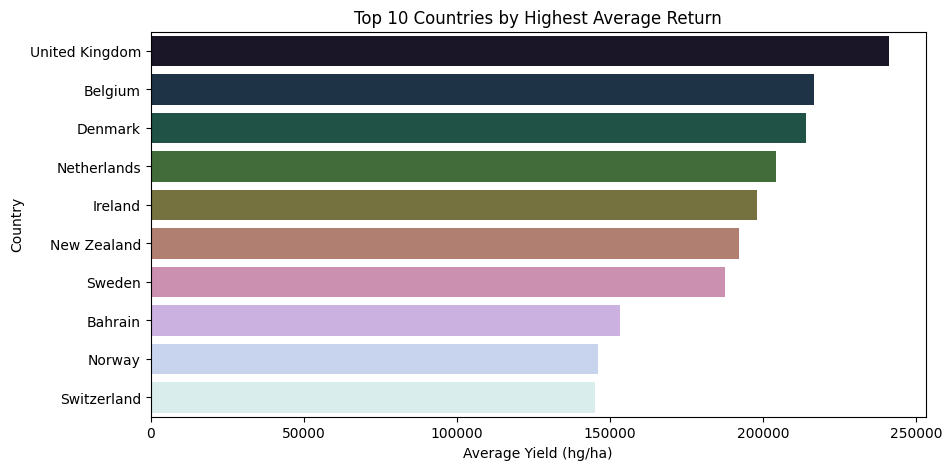

In [10]:
plt.figure(figsize=(10, 5))

top_countries = df.groupby("Area")["hg/ha_yield"].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, legend=False, palette="cubehelix")
plt.title("Top 10 Countries by Highest Average Return")
plt.xlabel("Average Yield (hg/ha)")
plt.ylabel("Country")
plt.show()

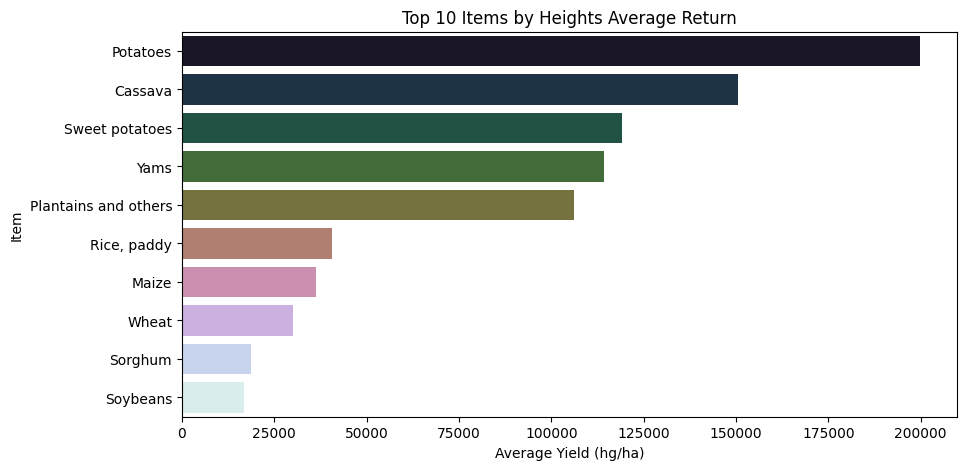

In [11]:
plt.figure(figsize=(10, 5))

top_items = df.groupby('Item')["hg/ha_yield"].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_items.values, y=top_items.index, hue=top_items.index, legend=False, palette="cubehelix")
plt.title('Top 10 Items by Heights Average Return')
plt.xlabel("Average Yield (hg/ha)")
plt.ylabel("Item")
plt.show()

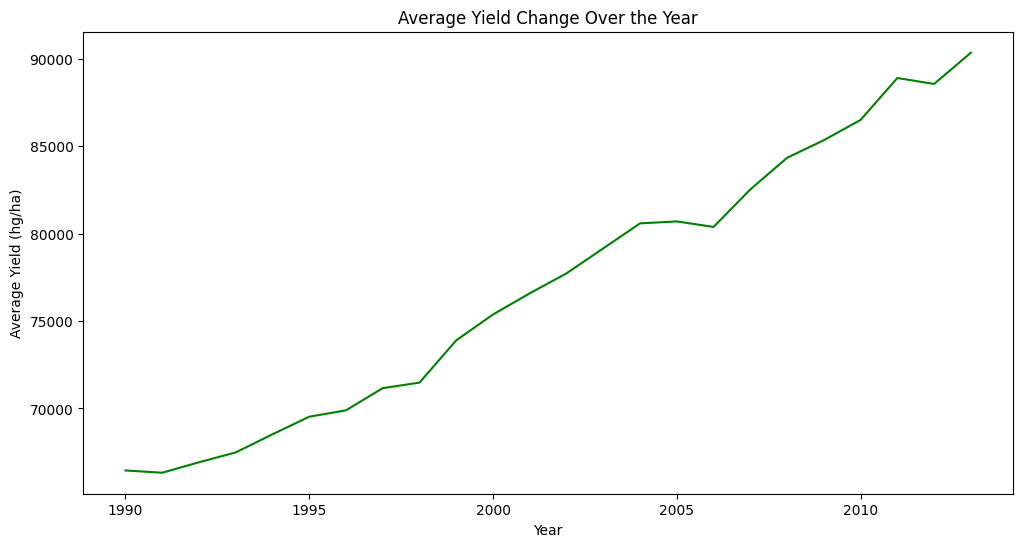

In [12]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="Year",
    y="hg/ha_yield",
    errorbar=None,
    color="green"
)
plt.title("Average Yield Change Over the Year")
plt.xlabel("Year")
plt.ylabel("Average Yield (hg/ha)")
plt.show()

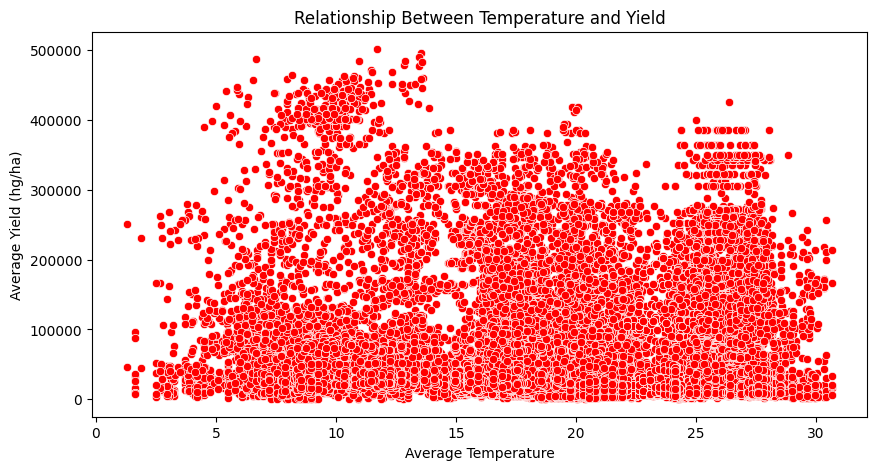

In [13]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="avg_temp",
    y="hg/ha_yield",
    color="red"
)
plt.title("Relationship Between Temperature and Yield")
plt.xlabel("Average Temperature")
plt.ylabel("Average Yield (hg/ha)")
plt.show()

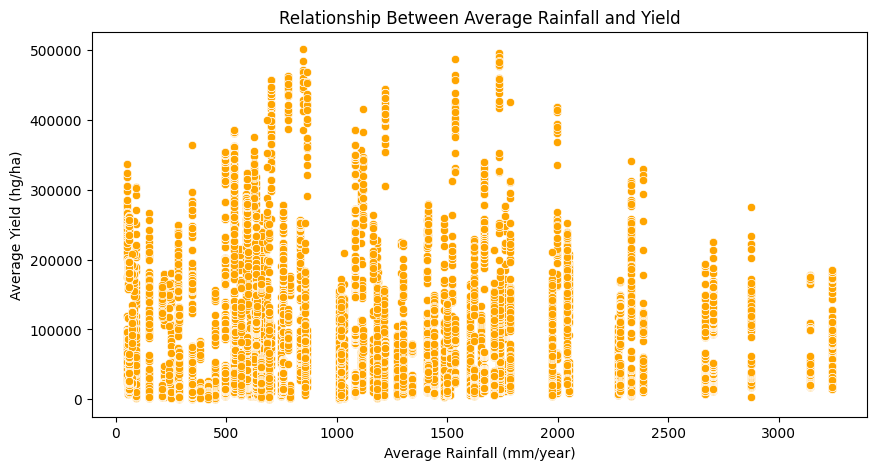

In [14]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, 
    x="average_rain_fall_mm_per_year",
    y="hg/ha_yield",
    color="orange"
)
plt.title("Relationship Between Average Rainfall and Yield")
plt.xlabel("Average Rainfall (mm/year)")
plt.ylabel("Average Yield (hg/ha)")
plt.show()

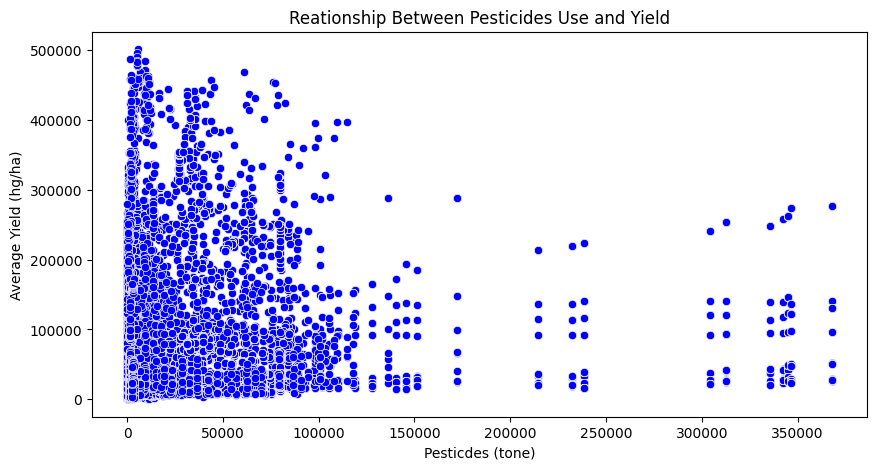

In [15]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="pesticides_tonnes",
    y="hg/ha_yield",
    color="blue"
)
plt.title("Reationship Between Pesticides Use and Yield")
plt.xlabel("Pesticdes (tone)")
plt.ylabel("Average Yield (hg/ha)")
plt.show()

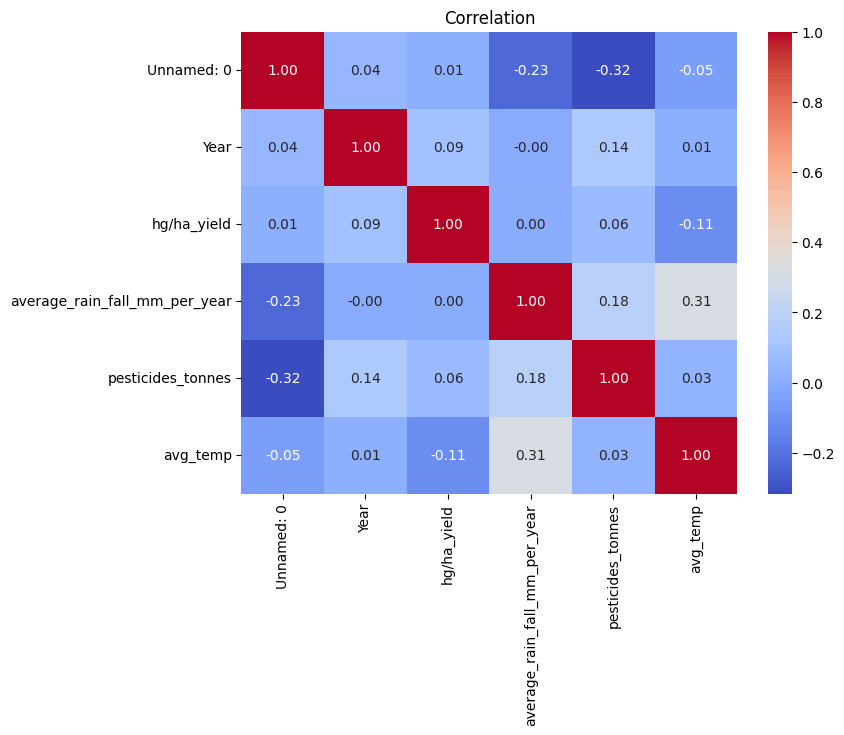

In [16]:
plt.figure(figsize=(8, 6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt='.2f')
plt.title("Correlation")
plt.show()

In [17]:
X = df.drop(["hg/ha_yield", "Area"], axis=1)
y = df["hg/ha_yield"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
ohe_cols = ["Item"]

transformer = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(drop="first", handle_unknown='ignore'), ohe_cols)
    ],
    remainder='passthrough'
)

In [20]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [21]:
encoded_cols = transformer.get_feature_names_out()

In [22]:
encoded_cols

array(['ohe__Item_Maize', 'ohe__Item_Plantains and others',
       'ohe__Item_Potatoes', 'ohe__Item_Rice, paddy', 'ohe__Item_Sorghum',
       'ohe__Item_Soybeans', 'ohe__Item_Sweet potatoes',
       'ohe__Item_Wheat', 'ohe__Item_Yams', 'remainder__Unnamed: 0',
       'remainder__Year', 'remainder__average_rain_fall_mm_per_year',
       'remainder__pesticides_tonnes', 'remainder__avg_temp'],
      dtype=object)

In [23]:
X_train = pd.DataFrame(X_train, columns=encoded_cols)
X_test = pd.DataFrame(X_test, columns=encoded_cols)

In [24]:
def evaluate_model(true, predicted):
    mse = mean_squared_error(true, predicted)
    mae = mean_absolute_error(true, predicted)
    r2 = r2_score(true, predicted)
    return r2, mae, mse

In [25]:
models = {
    "Linear Regression" : LinearRegression(),
    "K Neighbors Regressor" : KNeighborsRegressor(),
    "Random Forest Regressor" : RandomForestRegressor(),
    "Decision Tree Regressor" : DecisionTreeRegressor(),
    "Ada Boost Regressor" : AdaBoostRegressor(),
    "Gradient Boosting Regressor" : GradientBoostingRegressor()
}

In [26]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2, train_mae, train_mse = evaluate_model(y_train_pred, y_train)
    test_r2, test_mae, test_mse = evaluate_model(y_test_pred, y_test)

    print(list(models.keys())[i])
    print("Model Performance for Training Data")
    print("R2 Score: ", train_r2)
    print("Mean Absolute Error: ", train_mae)
    print("Mean Squared Error: ", train_mse)
    print("-------------------------------------------")

    print("Model Performance for Testing Data")
    print("R2 Score: ", test_r2)
    print("Mean Absolute Error: ", test_mae)
    print("Mean Squared Error: ", test_mse)
    print("-------------------------------------------")
    print("\n")

Linear Regression
Model Performance for Training Data
R2 Score:  0.4533046926483394
Mean Absolute Error:  31685.727327675668
Mean Squared Error:  2547845358.147229
-------------------------------------------
Model Performance for Testing Data
R2 Score:  0.46629289350412395
Mean Absolute Error:  31619.690650884706
Mean Squared Error:  2524620461.7116027
-------------------------------------------


K Neighbors Regressor
Model Performance for Training Data
R2 Score:  0.2915203545027505
Mean Absolute Error:  33673.79867215509
Mean Squared Error:  2804668124.7221794
-------------------------------------------
Model Performance for Testing Data
R2 Score:  -0.2500829012302439
Mean Absolute Error:  43517.6331740131
Mean Squared Error:  4325121269.401416
-------------------------------------------


Random Forest Regressor
Model Performance for Training Data
R2 Score:  0.99818104785435
Mean Absolute Error:  1337.5199583941928
Mean Squared Error:  12963977.696921717
----------------------------